# Part 3 — Greek Sensitivity Across Market Regimes

**Goal**: Quantify how the sensitivity of option Greeks (delta, gamma, vega, theta) to market moves changes across the four HMM-identified regimes.

**Model**: ΔGreek = α + β₁·ΔMarket + β₂·ΔVIX + Σγₖ·(Regimeₖ × ΔMarket) + ε

The γₖ coefficients measure additional Greek sensitivity vs. the calm baseline.

**Samples**:
- Primary: 20–45 DTE (active hedging window)
- Robustness: 5–20 DTE (FOMC window)

**Stratification**: Puts and calls analyzed separately. Moneyness buckets: deep OTM, OTM, ATM.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from panel import build_panel
from sensitivity import run_all, interaction_table
from plots import plot_sensitivity_heatmap, plot_put_call_comparison

DATA = '../data'

In [2]:
# Load regime labels from Part 2
regime_labels = pd.read_parquet(f'{DATA}/regime_labels.parquet')
regime_labels['date'] = pd.to_datetime(regime_labels['date'])
print(regime_labels['regime'].value_counts())

# Load market features for regression covariates
ff3 = pd.read_parquet(f'{DATA}/ff3.parquet')
ff3['date'] = pd.to_datetime(ff3['date'])
vix = pd.read_parquet(f'{DATA}/cboeall1986.parquet')
vix['date'] = pd.to_datetime(vix['Date'])
market_features = ff3[['date','mktrf']].merge(vix[['date','vix']].dropna(), on='date', how='inner')
market_features = market_features[
    (market_features['date'] >= '1996-01-01') & (market_features['date'] <= '2019-12-31')
]

regime
rising_stress    1854
recovery         1762
calm             1495
crisis            911
Name: count, dtype: int64


In [3]:
# Build primary sample panel (20–45 DTE)
puts, calls = build_panel(
    f'{DATA}/spx_raw.parquet',
    regime_labels,
    market_features,
    dte_min=20,
    dte_max=45,
)
print(f'Puts panel: {len(puts):,} observations | {puts["contract_id"].nunique():,} contracts')
print(f'Calls panel: {len(calls):,} observations | {calls["contract_id"].nunique():,} contracts')

Puts panel: 738,118 observations | 69,552 contracts
Calls panel: 460,886 observations | 42,313 contracts


In [4]:
# Run all regressions — puts
puts_results = run_all(puts)
puts_results.head(20)

,greek,moneyness,parameter,coef,se,t_stat,p_value,significant,n_obs
0,delta,deep_otm,const,0.004384,2.420966e-05,181.100572,0.000000e+00,True,458930
1,delta,deep_otm,mktrf,2.144310,1.042750e-02,205.639985,0.000000e+00,True,458930
2,delta,deep_otm,vix_chg,-0.002248,4.341417e-05,-51.775503,0.000000e+00,True,458930
3,delta,deep_otm,interact_crisis,-1.246579,1.541086e-02,-80.889624,0.000000e+00,True,458930
4,delta,deep_otm,interact_recovery,-0.778433,1.266279e-02,-61.474025,0.000000e+00,True,458930
5,delta,deep_otm,interact_rising_stress,-0.408972,1.384347e-02,-29.542625,8.168102e-192,True,458930
6,delta,otm,const,0.008482,7.297797e-05,116.223465,0.000000e+00,True,135140
7,delta,otm,mktrf,7.979638,3.230053e-02,247.043583,0.000000e+00,True,135140
8,delta,otm,vix_chg,-0.004856,1.597924e-04,-30.391616,7.089193e-203,True,135140
9,delta,otm,interact_crisis,-5.451268,3.936181e-02,-138.491308,0.000000e+00,True,135140


In [5]:
# Run all regressions — calls
calls_results = run_all(calls)
calls_results.head(20)

,greek,moneyness,parameter,coef,se,t_stat,p_value,significant,n_obs
0,delta,deep_otm,const,-0.006534,5.356369e-05,-121.979065,0.000000e+00,True,201917
1,delta,deep_otm,mktrf,3.487906,2.338134e-02,149.174773,0.000000e+00,True,201917
2,delta,deep_otm,vix_chg,-0.000546,5.759006e-05,-9.486290,2.394025e-21,True,201917
3,delta,deep_otm,interact_crisis,-2.498248,2.798136e-02,-89.282562,0.000000e+00,True,201917
4,delta,deep_otm,interact_recovery,-1.469465,2.884940e-02,-50.935736,0.000000e+00,True,201917
5,delta,deep_otm,interact_rising_stress,-1.059552,3.191640e-02,-33.197724,1.161120e-241,True,201917
6,delta,otm,const,-0.006661,1.078522e-04,-61.759815,0.000000e+00,True,85138
7,delta,otm,mktrf,10.248862,4.263722e-02,240.373611,0.000000e+00,True,85138
8,delta,otm,vix_chg,-0.003638,1.767226e-04,-20.583768,3.836671e-94,True,85138
9,delta,otm,interact_crisis,-7.341752,5.882924e-02,-124.797652,0.000000e+00,True,85138


In [6]:
# Interaction coefficient table (γ matrix)
print('PUTS — Interaction (γ) coefficients:')
display(interaction_table(puts_results))
print('\nCALLS — Interaction (γ) coefficients:')
display(interaction_table(calls_results))

PUTS — Interaction (γ) coefficients:


greek         delta                             gamma                          \
regime       crisis  recovery rising_stress    crisis  recovery rising_stress   
moneyness                                                                       
atm       -7.323636 -4.788486     -3.297211 -0.002882 -0.000824      0.000788   
deep_otm  -1.246579 -0.778433     -0.408972  0.020007  0.014919      0.008554   
otm       -5.451268 -3.458768     -2.302877  0.043037  0.034382      0.024926   

greek            theta                                   vega               \
regime          crisis    recovery rising_stress       crisis     recovery   
moneyness                                                                    
atm         -89.020324  354.979140    472.064232   -94.265538  -184.460042   
deep_otm   -615.029089  -62.473535     98.390091  1393.328488   771.901934   
otm       -1064.011000  -41.052410    231.087080  2256.323127  1324.204075   

greek                    
regime    rising_stress  
moneyness                
atm         -268.881633  
deep_otm     478.452010  
otm          859.293207


CALLS — Interaction (γ) coefficients:


greek         delta                             gamma                          \
regime       crisis  recovery rising_stress    crisis  recovery rising_stress   
moneyness                                                                       
atm       -7.728462 -4.907790     -3.387563 -0.012693 -0.010975     -0.005118   
deep_otm  -2.498248 -1.469465     -1.059552 -0.078241 -0.060732     -0.040924   
otm       -7.341752 -4.578599     -3.125586 -0.090140 -0.071937     -0.046552   

greek           theta                                   vega               \
regime         crisis    recovery rising_stress       crisis     recovery   
moneyness                                                                   
atm       -274.686162 -114.086403    229.748700  -321.532890  -213.905699   
deep_otm   621.425312  136.172277    223.591482 -2373.353385 -1371.982519   
otm        711.783043  282.830203    410.042550 -3148.258706 -2025.118733   

greek                    
regime    rising_stress  
moneyness                
atm         -250.534794  
deep_otm   -1012.365022  
otm        -1534.065963

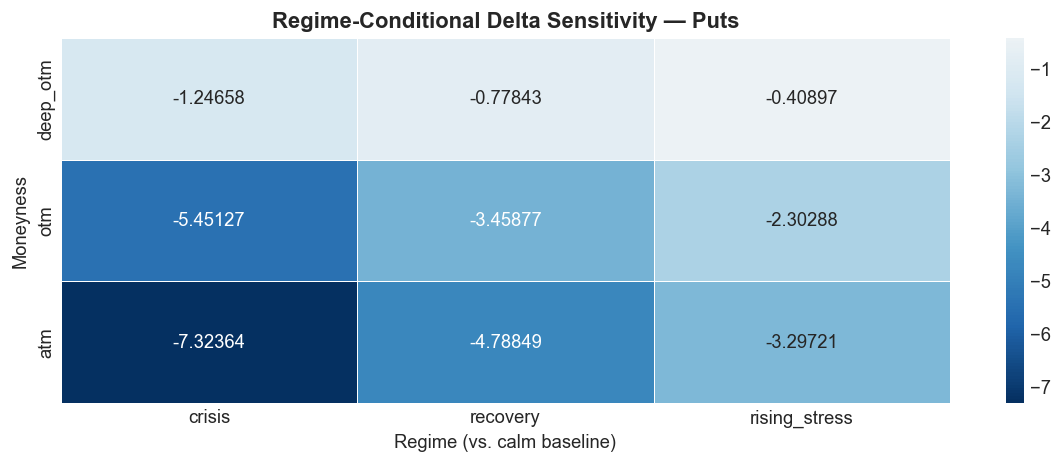

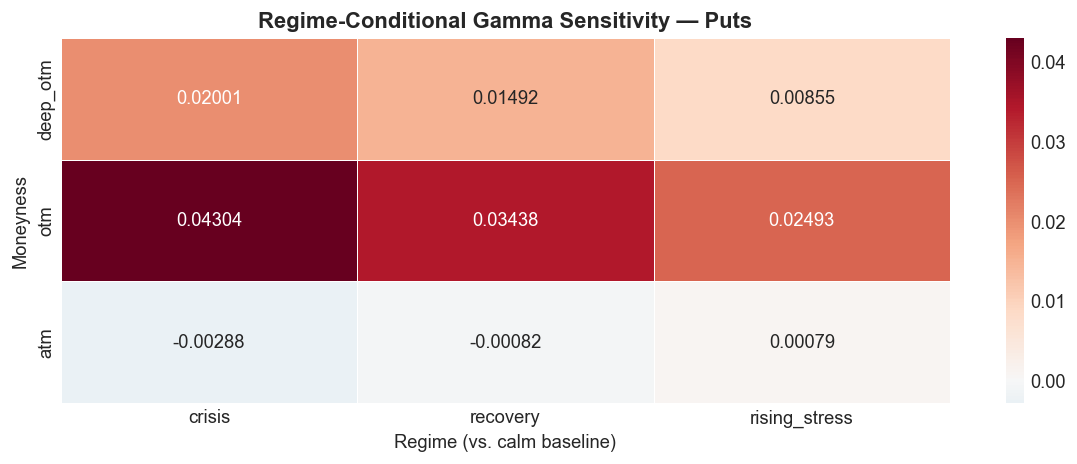

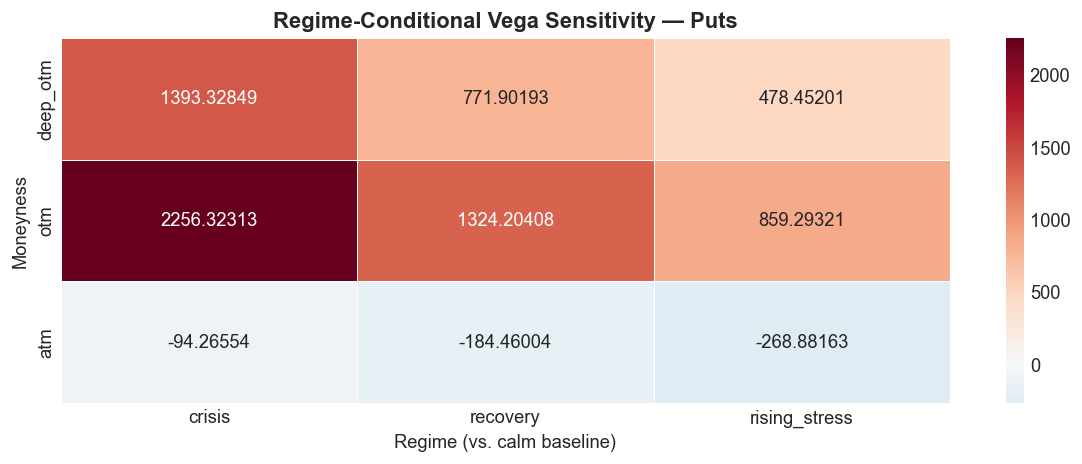

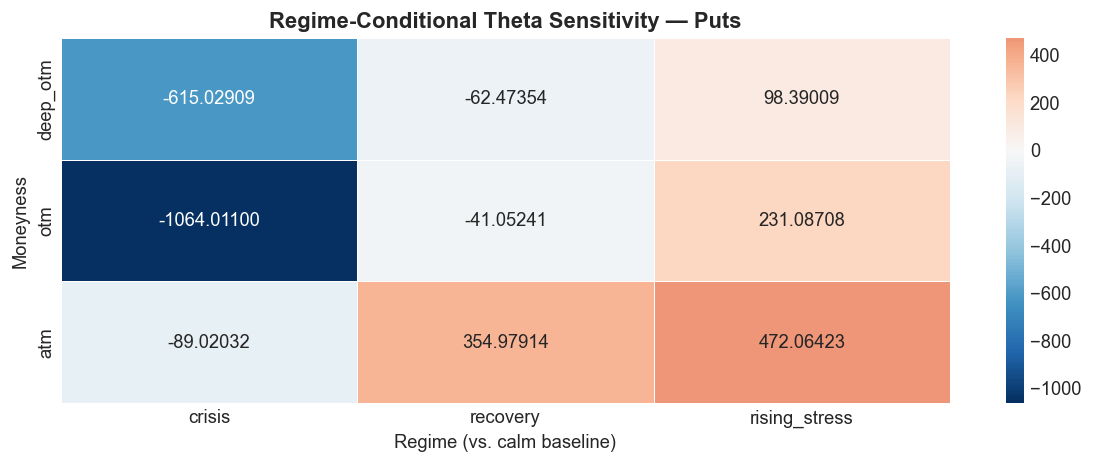

In [7]:
# Heatmaps — puts
for greek in ['delta', 'gamma', 'vega', 'theta']:
    fig = plot_sensitivity_heatmap(puts_results, greek, instrument='puts')
    plt.show()

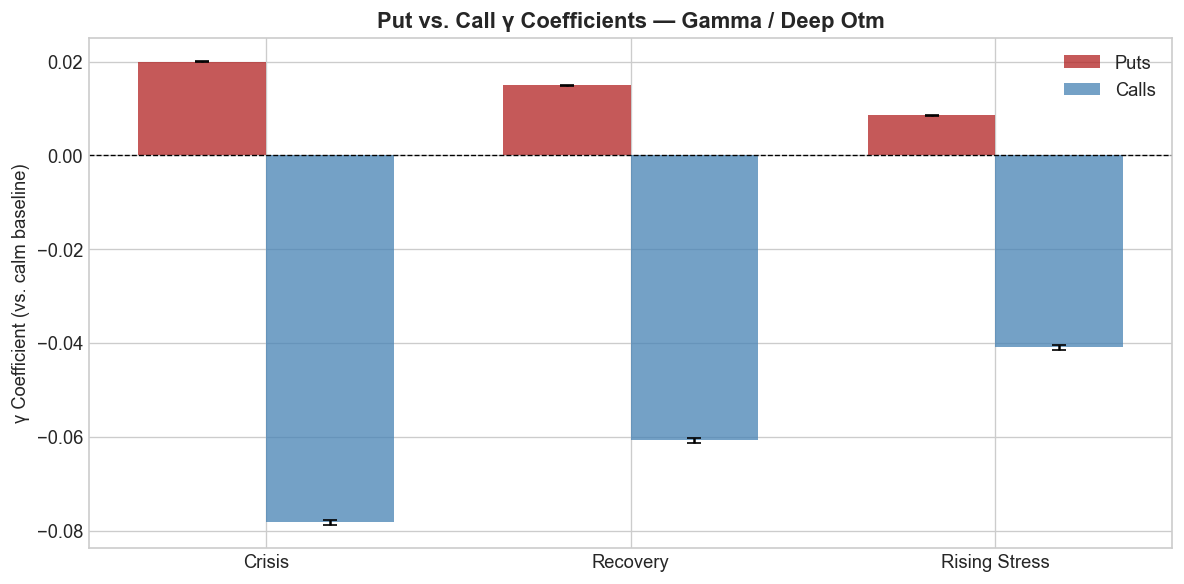

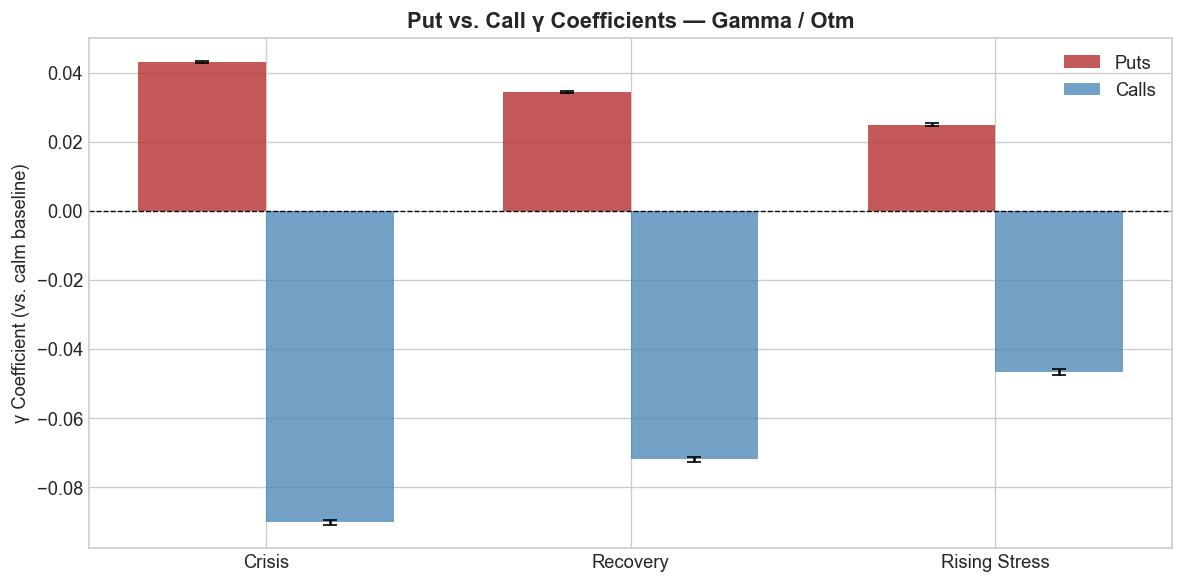

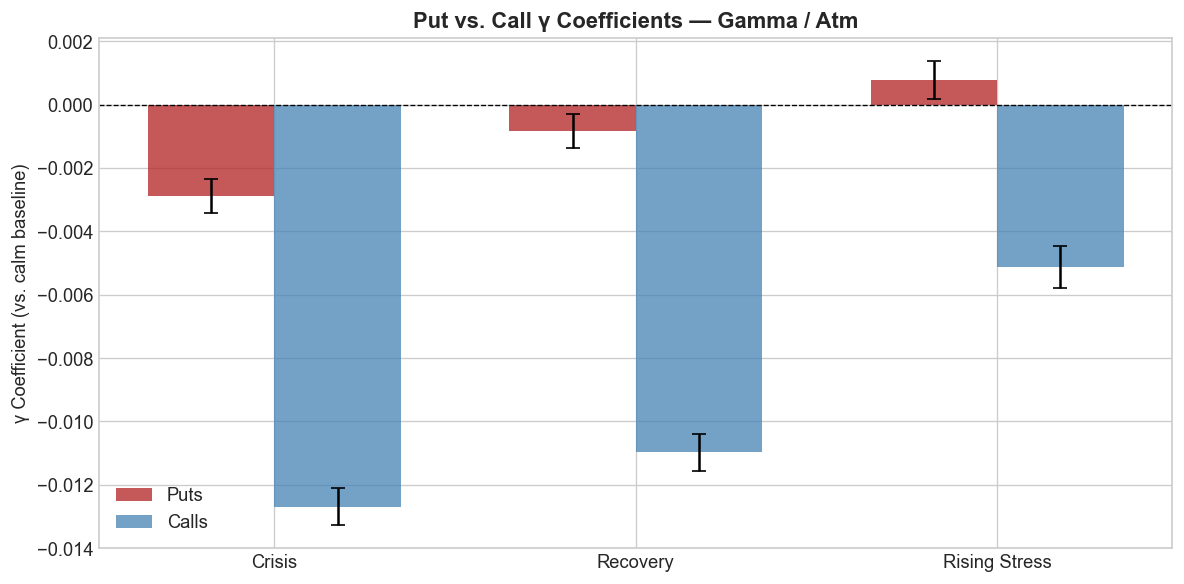

In [8]:
# Put vs. call comparison for gamma (the most hedging-relevant Greek)
for bucket in ['deep_otm', 'otm', 'atm']:
    fig = plot_put_call_comparison(puts_results, calls_results, 'gamma', bucket)
    plt.show()

In [9]:
# Robustness: FOMC window (5–20 DTE)
puts_fomc, calls_fomc = build_panel(
    f'{DATA}/spx_raw.parquet',
    regime_labels,
    market_features,
    dte_min=5,
    dte_max=20,
)
print(f'FOMC puts: {len(puts_fomc):,} | calls: {len(calls_fomc):,}')
puts_fomc_results = run_all(puts_fomc)
calls_fomc_results = run_all(calls_fomc)
print('\nFOMC Puts γ:')
display(interaction_table(puts_fomc_results))

FOMC puts: 566,162 | calls: 351,048



FOMC Puts γ:


greek          delta                             gamma            \
regime        crisis  recovery rising_stress    crisis  recovery   
moneyness                                                          
atm       -12.565574 -8.945259     -6.640956 -0.038955 -0.031476   
deep_otm   -1.282930 -0.805552     -0.551459  0.044733  0.034232   
otm        -9.821400 -6.848477     -5.149549  0.110738  0.092628   

greek                          theta                                    vega  \
regime    rising_stress       crisis     recovery rising_stress       crisis   
moneyness                                                                      
atm           -0.026791  -179.669443  1730.766631   1675.622762  -291.214804   
deep_otm       0.023960   -86.872619   591.435458    534.019601  1042.357371   
otm            0.070482 -1713.230611   964.056638   1167.338170  2289.248597   

greek                                 
regime        recovery rising_stress  
moneyness                             
atm        -479.194692   -505.620434  
deep_otm    576.331149    405.643778  
otm        1360.516260    921.685848